# LAB | Imbalanced

**Load the data**

In this challenge, we will be working with Credit Card Fraud dataset.

https://raw.githubusercontent.com/data-bootcamp-v4/data/main/card_transdata.csv

Metadata

- **distance_from_home:** the distance from home where the transaction happened.
- **distance_from_last_transaction:** the distance from last transaction happened.
- **ratio_to_median_purchase_price:** Ratio of purchased price transaction to median purchase price.
- **repeat_retailer:** Is the transaction happened from same retailer.
- **used_chip:** Is the transaction through chip (credit card).
- **used_pin_number:** Is the transaction happened by using PIN number.
- **online_order:** Is the transaction an online order.
- **fraud:** Is the transaction fraudulent. **0=legit** -  **1=fraud**


In [1]:
#Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [2]:
fraud = pd.read_csv("https://raw.githubusercontent.com/data-bootcamp-v4/data/main/card_transdata.csv")
fraud.head()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0


**Steps:**

- **1.** What is the distribution of our target variable? Can we say we're dealing with an imbalanced dataset?
- **2.** Train a LogisticRegression.
- **3.** Evaluate your model. Take in consideration class importance, and evaluate it by selection the correct metric.
- **4.** Run **Oversample** in order to balance our target variable and repeat the steps above, now with balanced data. Does it improve the performance of our model? 
- **5.** Now, run **Undersample** in order to balance our target variable and repeat the steps above (1-3), now with balanced data. Does it improve the performance of our model?
- **6.** Finally, run **SMOTE** in order to balance our target variable and repeat the steps above (1-3), now with balanced data. Does it improve the performance of our model? 

In [3]:
fraud.shape

(1000000, 8)

In [4]:
fraud.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 8 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   distance_from_home              1000000 non-null  float64
 1   distance_from_last_transaction  1000000 non-null  float64
 2   ratio_to_median_purchase_price  1000000 non-null  float64
 3   repeat_retailer                 1000000 non-null  float64
 4   used_chip                       1000000 non-null  float64
 5   used_pin_number                 1000000 non-null  float64
 6   online_order                    1000000 non-null  float64
 7   fraud                           1000000 non-null  float64
dtypes: float64(8)
memory usage: 61.0 MB


In [5]:
fraud.isna().sum()

distance_from_home                0
distance_from_last_transaction    0
ratio_to_median_purchase_price    0
repeat_retailer                   0
used_chip                         0
used_pin_number                   0
online_order                      0
fraud                             0
dtype: int64

In [6]:
# Check target distribution
fraud["fraud"].value_counts()

fraud
0.0    912597
1.0     87403
Name: count, dtype: int64

In [7]:
# Check target distribution in percentages
fraud["fraud"].value_counts(normalize=True)

fraud
0.0    0.912597
1.0    0.087403
Name: proportion, dtype: float64

### Target distribution

The target variable is `fraud`, where:

- 0 = legitimate transaction
- 1 = fraudulent transaction

We check the distribution of the target variable to see whether the dataset is imbalanced.

In [8]:
# Features and target
X = fraud.drop(columns=["fraud"])
y = fraud["fraud"]

In [9]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.utils import resample

In [11]:
# Baseline Logistic Regression model
baseline_model = LogisticRegression(max_iter=1000)

baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)

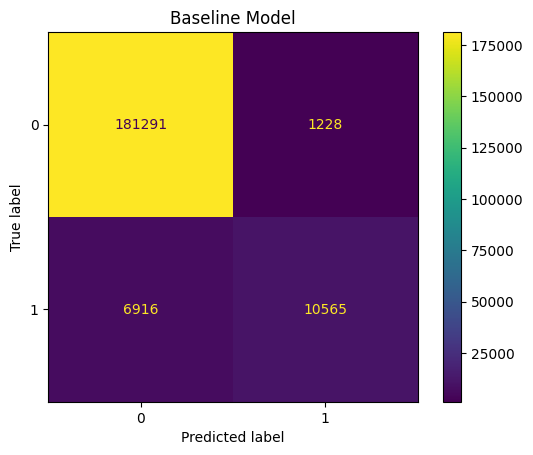

In [12]:
# Baseline confusion matrix
cm = confusion_matrix(y_test, baseline_pred)

ConfusionMatrixDisplay(cm).plot()
plt.title("Baseline Model")
plt.show()

### Baseline model evaluation

The baseline Logistic Regression model performs reasonably well despite the class imbalance.

The model correctly identifies many legitimate transactions and also detects a substantial number of fraudulent transactions.

However, there are still many false negatives, meaning fraudulent transactions that were classified as legitimate transactions. In fraud detection, false negatives are particularly problematic because fraudulent activity goes undetected.

In [13]:
# Create training dataframe
train_df = X_train.copy()

train_df["fraud"] = y_train

In [14]:
# Separate classes
fraud_positive = train_df[train_df["fraud"] == 1]
fraud_negative = train_df[train_df["fraud"] == 0]

In [15]:
# Oversample minority class
fraud_positive_oversampled = resample(
    fraud_positive,
    replace=True,
    n_samples=len(fraud_negative),
    random_state=42
)

In [16]:
# Combine data
fraud_over = pd.concat([
    fraud_negative,
    fraud_positive_oversampled
])

In [17]:
# Check new balance
fraud_over["fraud"].value_counts()

fraud
0.0    730078
1.0    730078
Name: count, dtype: int64

In [18]:
# Split oversampled features and target
X_train_over = fraud_over.drop(columns=["fraud"])
y_train_over = fraud_over["fraud"]

In [19]:
# Train Logistic Regression with oversampled data
oversampled_model = LogisticRegression(max_iter=1000)

oversampled_model.fit(X_train_over, y_train_over)

oversampled_pred = oversampled_model.predict(X_test)

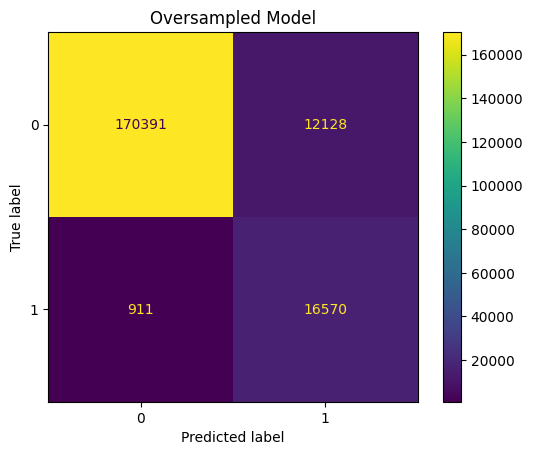

In [20]:
# Oversampled confusion matrix
cm = confusion_matrix(y_test, oversampled_pred)

ConfusionMatrixDisplay(cm).plot()
plt.title("Oversampled Model")
plt.show()

### Oversampled model evaluation

After applying random oversampling, the model detects substantially more fraudulent transactions.

The number of false negatives decreases significantly, meaning fewer fraud cases go undetected.

However, the number of false positives increases considerably. This means that more legitimate transactions are incorrectly classified as fraud.

This demonstrates the typical tradeoff in imbalanced classification problems:
improving fraud detection often leads to more false alarms.

In [21]:
# Undersample majority class
fraud_negative_undersampled = resample(
    fraud_negative,
    replace=False,
    n_samples=len(fraud_positive),
    random_state=42
)

In [22]:
# Combine data
fraud_under = pd.concat([
    fraud_negative_undersampled,
    fraud_positive
])

In [23]:
# Check new balance
fraud_under["fraud"].value_counts()

fraud
0.0    69922
1.0    69922
Name: count, dtype: int64

In [24]:
# Split undersampled features and target
X_train_under = fraud_under.drop(columns=["fraud"])
y_train_under = fraud_under["fraud"]

In [25]:
# Train Logistic Regression with undersampled data
undersampled_model = LogisticRegression(max_iter=1000)

undersampled_model.fit(X_train_under, y_train_under)

undersampled_pred = undersampled_model.predict(X_test)


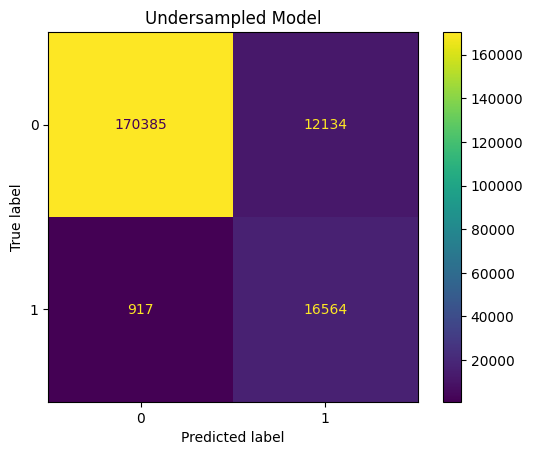

In [26]:
# Undersampled confusion matrix
cm = confusion_matrix(y_test, undersampled_pred)

ConfusionMatrixDisplay(cm).plot()
plt.title("Undersampled Model")
plt.show()

### Undersampled model evaluation

The undersampled model produces results very similar to the oversampled model.

The number of detected fraudulent transactions increases significantly compared to the baseline model, while false negatives decrease substantially.

However, the model still generates many false positives.

One disadvantage of undersampling is that a large amount of majority class data is removed, which may lead to loss of potentially useful information.

In [27]:
from imblearn.over_sampling import SMOTE

In [28]:
# Apply SMOTE
smote = SMOTE(random_state=42)

X_smote, y_smote = smote.fit_resample(
    X_train,
    y_train
)

In [29]:
# Check new balance
pd.Series(y_smote).value_counts()

fraud
0.0    730078
1.0    730078
Name: count, dtype: int64

In [30]:
# Train Logistic Regression with SMOTE data
smote_model = LogisticRegression(max_iter=1000)

smote_model.fit(X_smote, y_smote)

smote_pred = smote_model.predict(X_test)

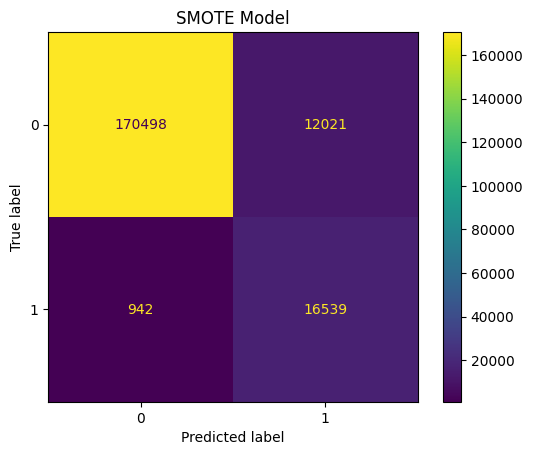

In [31]:
# SMOTE confusion matrix
cm = confusion_matrix(y_test, smote_pred)

ConfusionMatrixDisplay(cm).plot()
plt.title("SMOTE Model")
plt.show()

### SMOTE model evaluation

The SMOTE model also improves fraud detection significantly compared to the baseline model.

The number of false negatives decreases substantially, meaning that far fewer fraudulent transactions go undetected.

Compared to random oversampling and undersampling, the SMOTE model produces very similar results.

SMOTE is often considered a more sophisticated balancing technique because it creates synthetic minority samples instead of simply duplicating existing observations.

## Final conclusion

The original dataset was imbalanced, with legitimate transactions representing the large majority of observations.

The baseline Logistic Regression model already performed reasonably well, but it still missed many fraudulent transactions.

After applying oversampling, undersampling, and SMOTE, the models detected substantially more fraud cases and reduced the number of false negatives considerably.

However, all balancing techniques also increased the number of false positives, demonstrating the common tradeoff in fraud detection problems:
improving fraud detection often leads to more false alarms.

Overall, SMOTE produced results similar to oversampling and undersampling while using a more advanced synthetic sampling approach.